# Process aggregated time-series data from Google Earth Engine
This code snippet provides an example of accessing data from Google Earth Engine, aggregating over a spatial area, and creating a time-series over multiple timesteps, using the earthengine-api for Python (read the [docs](https://developers.google.com/earth-engine/tutorials/community/intro-to-python-api)). We will use the server side processing of GEE to perform the aggregations.

You will first need to register for a (free) Google Cloud project account.

In this snippet, we will cover two examples: 

* __A) Annual land cover data using the USDA NASS Cropland Data Layer:__ creating a multiband image stack of years, mapping the aggregate statistics function over multiple counties. 

* __B) Daily precipitation data using CHIRPS:__ mapping the aggregate statistics function over multiple images in a daily precipitation image collection for a single region.

You can browse other available datasets in the [Earth Engine Catalog](https://developers.google.com/earth-engine/datasets/catalog). There is also the [awesome-gee-community-catalog](https://gee-community-catalog.org/projects/) providing additional datasets contributed by the open-source community.

## Setup

In [1]:
# Install earthengine-api
# !pip install earthengine-api
# !pip install geemap
# !pip install geedim

In [2]:
from pathlib import Path
import ee
import geemap
import xarray as xr
from shapely import box
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
# Trigger the authentication flow
ee.Authenticate()

# Initialize the library
# You will need to follow the link, then copy and paste the verification code
ee.Initialize() #project='my-project'

# Example A: Annual land cover data using the USDA NASS Cropland Data Layer

* Annual crop land cover classification
* Extract layer for almonds in California (available from 2008 onwards)
* Aggregate over county boundaries
* Create 20 year time series of Corn % area for each county  

In [4]:
# Define collections

# US counties
counties = ee.FeatureCollection("TIGER/2018/Counties")

# Cropland Data Layer
cdl = ee.ImageCollection("USDA/NASS/CDL")

# Define start and end dates for CDL data
start_year, end_year = '2008', '2026'

### Prep / pre-processing steps

In [5]:
# Get feature collection of California counties - FP code 06
ca_counties = counties.filter(ee.Filter.eq('STATEFP', '06'))

# Filter the CDL by date range and select the Cropland layer
cropland_ic = cdl.filter(ee.Filter.date(start_year, end_year)).select('cropland')

# Create multiband image containing annual CDL data, each year as a band
cropland_multiband = cropland_ic.toBands()

# Clean band names - set each band name as the year
band_names = cropland_multiband.bandNames()
clean_names = band_names.map(lambda name: ee.String(name).split('_').get(0))
cropland_multiband = cropland_multiband.rename(clean_names)

# Get just pixels for almond - class id 75
almond_multiband = cropland_multiband.eq(75)

### Map plotting

In [6]:
Map = geemap.Map()

# Get the most recent cropland data layer and almond layer, clipped to California
cropland_im = cropland_ic.sort('system:time_start', False).first().clip(ca_counties)
almomd_im = cropland_im.eq(75).selfMask().visualize(palette=['red'])

# Map.addLayer(cropland_im, {}, 'Cropland Data Layer 2025')
Map.addLayer(almomd_im, {}, 'Almonds 2025')

# Add county borders
counties_viz = ca_counties.style(color="black", fillColor="00000000", width=0.5)
Map.addLayer(counties_viz, {}, 'California counties')

Map.centerObject(ca_counties, 6)
Map

Map(center=[37.15243410485415, -119.52655155207282], controls=(WidgetControl(options=['position', 'transparent…

### Aggregation step

In [7]:
# Function to get stats for the annual CDL multiband image
# Add stats to each feature in the feature collection
def add_stats_per_feature(feature):
    stats = almond_multiband.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=feature.geometry(),
        scale=30,
        bestEffort=True)
    return feature.set(stats)

# Run the add_stats function on the counties
# For each county feature, adds almond mean (% area) stats for each band (year) in the multiband image
ca_counties_stats = ca_counties.map(add_stats_per_feature)

# Convert from ee feature collection to pandas geodataframe
ca_counties_stats_gdf = geemap.ee_to_gdf(ca_counties_stats)
ca_counties_stats_gdf.head()

,geometry,2008,2009,2010,2011,2012,2013,2014,2015,2016,...,FUNCSTAT,GEOID,INTPTLAT,INTPTLON,LSAD,METDIVFP,MTFCC,NAME,NAMELSAD,STATEFP
0,"POLYGON ((-122.64641 38.5986, -122.64632 38.59...",0.000185,0.000376,0.000769,0.000560,0.000004,0.000025,0.000313,0.000013,0.000427,...,A,06055,+38.5070999,-122.3259045,06,,G4020,Napa,Napa County,06
1,"POLYGON ((-123.13452 38.29626, -123.12613 38.2...",0.000000,0.000897,0.000074,0.000000,0.000000,0.000000,0.000006,0.000000,0.000020,...,A,06041,+38.0518169,-122.7459738,06,42034,G4020,Marin,Marin County,06
2,GEOMETRYCOLLECTION (LINESTRING (-122.25544 37....,0.000057,0.000254,0.000467,0.000831,0.000341,0.000139,0.001433,0.000269,0.000464,...,A,06013,+37.9194790,-121.9515431,06,36084,G4020,Contra Costa,Contra Costa County,06
3,"POLYGON ((-122.58816 37.57939, -122.58789 37.5...",0.000006,0.000007,0.000073,0.000000,0.000003,0.000000,0.000026,0.000000,0.000059,...,A,06081,+37.4146725,-122.3715457,06,41884,G4020,San Mateo,San Mateo County,06
4,GEOMETRYCOLLECTION (LINESTRING (-122.25521 37....,0.000020,0.000012,0.000053,0.000045,0.000026,0.000010,0.000185,0.000070,0.000107,...,A,06001,+37.6471385,-121.9124880,06,36084,G4020,Alameda,Alameda County,06


### Vizualization of aggregated results

In [8]:
# Plot the % area of almonds per county per year - this takes some time to run
years = range(int(start_year), int(end_year))
nplots = len(years)
ncols = 6
nrows = nplots // 6
fig, axes = plt.subplots(nrows, ncols, figsize=(15,8), constrained_layout=True)
for i, year in enumerate(years):
    ax = axes.ravel()[i]
    ca_counties_stats_gdf.plot(ax=ax, column=str(year), vmin=0, vmax=0.2, legend=True)
    ax.set_title(str(year))
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Counties % Area Almonds by Year')

Text(0.5, 0.98, 'Counties % Area Almonds by Year')

In [10]:
ca_counties_stats_gdf.iloc[[ca_counties_stats_gdf['2025'].idxmax()]]

,geometry,2008,2009,2010,2011,2012,2013,2014,2015,2016,...,FUNCSTAT,GEOID,INTPTLAT,INTPTLON,LSAD,METDIVFP,MTFCC,NAME,NAMELSAD,STATEFP
54,"POLYGON ((-121.48676 37.47566, -121.48645 37.4...",0.122952,0.126401,0.142667,0.150892,0.120232,0.155801,0.119271,0.164231,0.161638,...,A,06099,+37.5623162,-121.0028311,06,,G4020,Stanislaus,Stanislaus County,06


<Axes: title={'center': 'Stanislaus County % Area Almond by Year'}>

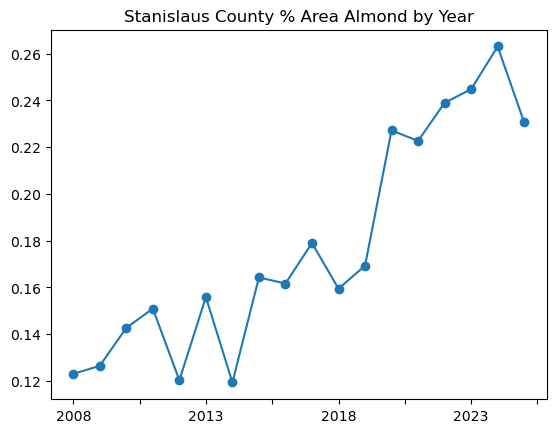

In [11]:
# Stanislaus County has the maximum almond % area in 2025 
# Get the years % area data and plot time series for the county
county_stats = ca_counties_stats_gdf.iloc[[ca_counties_stats_gdf['2025'].idxmax()]][[str(year) for year in years]].T
county_stats.plot(marker='o', legend=False, title='Stanislaus County % Area Almond by Year', xlabel='Year', ylabel='Fraction County Area Almonds')

# Example B: Daily precipitation data using CHIRPS

mapping the aggregate statistics function over multiple images in a daily precipitation image collection for a single region.

* Daily CHIRPS gridded precipitation data
* Extract mean for region
* Create time series of mean precipitation for the region over time  

In [4]:
# Define collections

# US counties
states = ee.FeatureCollection("TIGER/2018/States")

# CHIRPS daily precipitation
chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")

# Define start and end dates for CDL data
start_date, end_date = '2025-01-01', '2026-01-01'

### Prep / pre-processing steps

In [5]:
# Get feature collection of California state
ca = states.filter(ee.Filter.eq('NAME', 'California'))

# Filter CHIRPS by date range and select the precipitation layer
chirps_ic = chirps.filterBounds(ca).filterDate(start_date, end_date).select('precipitation')

### Map plotting

In [6]:
Map = geemap.Map()

precipVis = {'min': 1, 'max': 20,'palette': ['001137', '0aab1e', 'e7eb05', 'ff4a2d', 'e90000'],}

# Create mean composite from all the dates
chirps_mean = chirps_ic.mean()
Map.addLayer(chirps_mean.clip(ca), precipVis, 'CHIRPS Mean 2025-2026')

# Add single date to map
Map.addLayer(chirps_ic.first().clip(ca), precipVis, 'CHIRPS 2025-01-01')

# Add county borders
ca_viz = ca.style(color="black", fillColor="00000000", width=1)
Map.addLayer(ca_viz, {}, 'California')

Map.centerObject(ca, 6)
Map

Map(center=[37.15243410467134, -119.52655155150886], controls=(WidgetControl(options=['position', 'transparent…

### Aggregation step

In [7]:
# Function to get stats for a single daily CHIRPS image
# Creates feature collection containing date and mean precip
def add_stats_per_image(image):

    mean_precip = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=ca.geometry(),
        scale=5566,  # CHIRPS resolution
        maxPixels=1e13
    ).get('precipitation')

    return ee.Feature(None, {'date': image.date().format('YYYY-MM-dd'),
                             'mean_precip': mean_precip})

# Run the add_stats function on the image collection
# For each image, get the mean precip over california and return the mean precip and date
chirps_daily_mean = ee.FeatureCollection(chirps_ic.map(add_stats_per_image))

# Convert from ee feature collection to pandas geodataframe
chirps_daily_mean_df = geemap.ee_to_df(chirps_daily_mean)
chirps_daily_mean_df.head()

,date,mean_precip
0,2025-01-01,4.223026
1,2025-01-02,0.423861
2,2025-01-03,7.867993
3,2025-01-04,0.526411
4,2025-01-05,0.169591


<Axes: title={'center': 'California Average Daily Precipitation 2025'}, xlabel='Date', ylabel='Average Precipitation (mm/day)'>

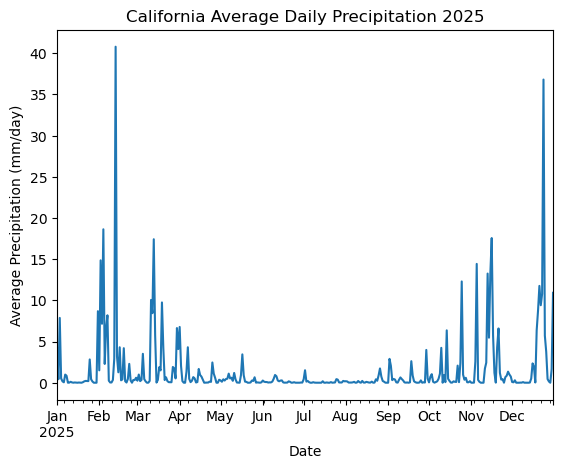

In [11]:
# Set datetime index and create quick plot
chirps_daily_mean_df['date'] = pd.to_datetime(chirps_daily_mean_df['date'])
chirps_daily_mean_df.set_index('date', inplace=True)
chirps_daily_mean_df.plot(title='California Average Daily Precipitation 2025', legend=False,
                          xlabel='Date', ylabel='Average Precipitation (mm/day)')